In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
processed_path = Path("../data/processed")

waterloo_da_pop = gpd.read_file(
    processed_path / "waterloo_da_population.gpkg"
)

In [3]:
print(waterloo_da_pop.shape)
print(waterloo_da_pop.crs)
print(waterloo_da_pop["Population"].sum())

(766, 6)
EPSG:26917
587165.0


In [4]:
gtfs_path = Path("../data/raw/gtfs")

stops = pd.read_csv(gtfs_path / "stops.txt")

transit_stops = stops[
    stops["location_type"] == 0
].copy()

stops_gdf = gpd.GeoDataFrame(
    transit_stops,
    geometry=gpd.points_from_xy(
        transit_stops["stop_lon"],
        transit_stops["stop_lat"]
    ),
    crs="EPSG:4326"
)

In [5]:
stops_projected = stops_gdf.to_crs("EPSG:26917")

In [6]:
print("Stops:", len(stops_projected))
print("Stops CRS:", stops_projected.crs)
print("DA CRS:", waterloo_da_pop.crs)

Stops: 2246
Stops CRS: EPSG:26917
DA CRS: EPSG:26917


In [7]:
buffer_400 = stops_projected.copy()

buffer_400["geometry"] = buffer_400.geometry.buffer(400)

In [8]:
access_400 = buffer_400.geometry.union_all()

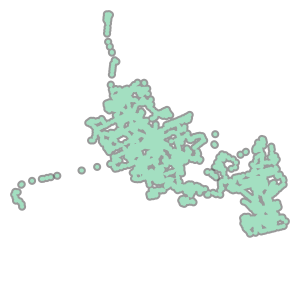

In [9]:
access_400

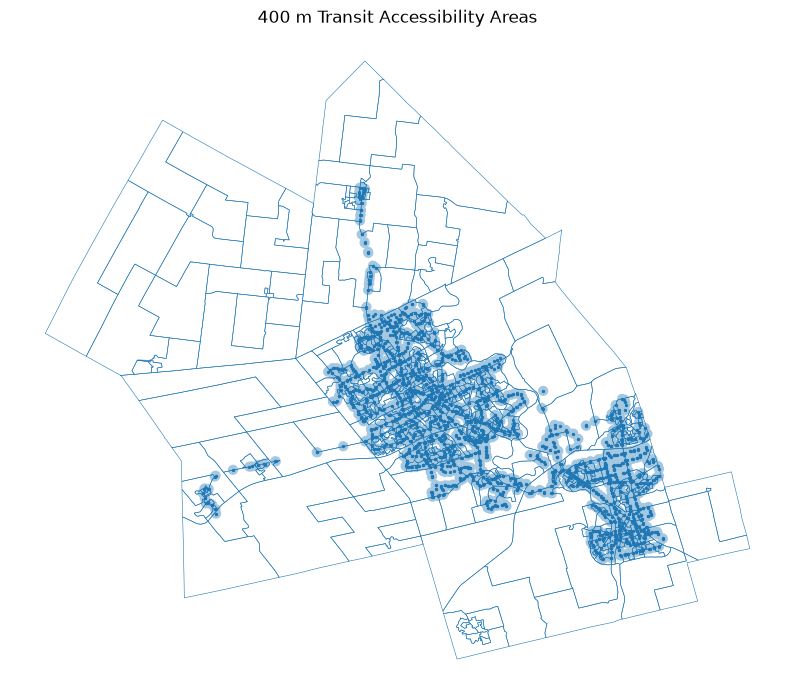

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

waterloo_da_pop.boundary.plot(
    ax=ax,
    linewidth=0.4
)

gpd.GeoSeries(
    [access_400],
    crs="EPSG:26917"
).plot(
    ax=ax,
    alpha=0.4
)

stops_projected.plot(
    ax=ax,
    markersize=2
)

ax.set_title("400 m Transit Accessibility Areas")
ax.set_axis_off()

plt.show()

In [11]:
buffer_800 = stops_projected.copy()

buffer_800["geometry"] = buffer_800.geometry.buffer(800)

access_800 = buffer_800.geometry.union_all()

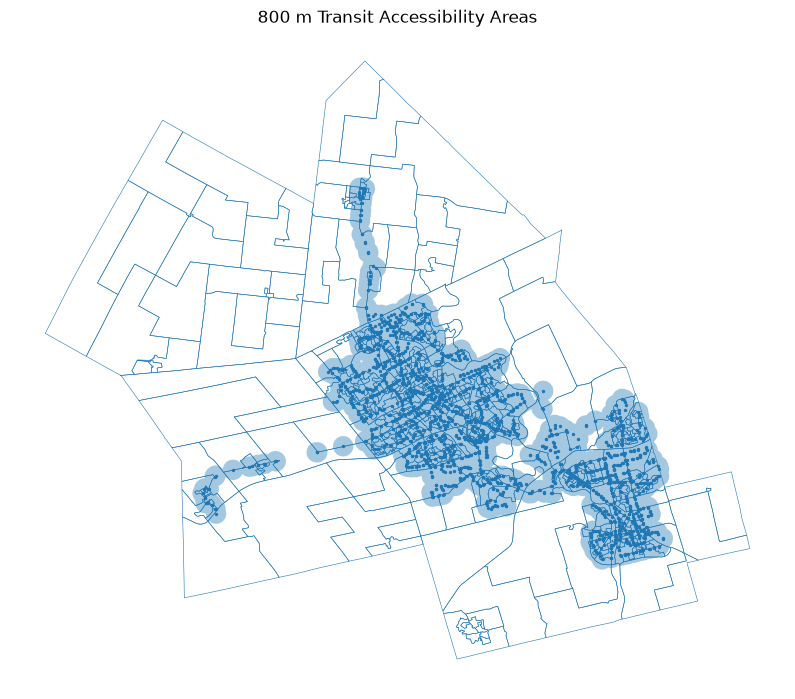

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

waterloo_da_pop.boundary.plot(
    ax=ax,
    linewidth=0.4
)

gpd.GeoSeries(
    [access_800],
    crs="EPSG:26917"
).plot(
    ax=ax,
    alpha=0.4
)

stops_projected.plot(
    ax=ax,
    markersize=2
)

ax.set_title("800 m Transit Accessibility Areas")
ax.set_axis_off()

plt.show()

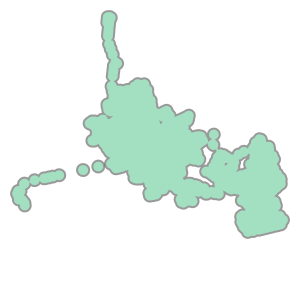

In [13]:
access_800

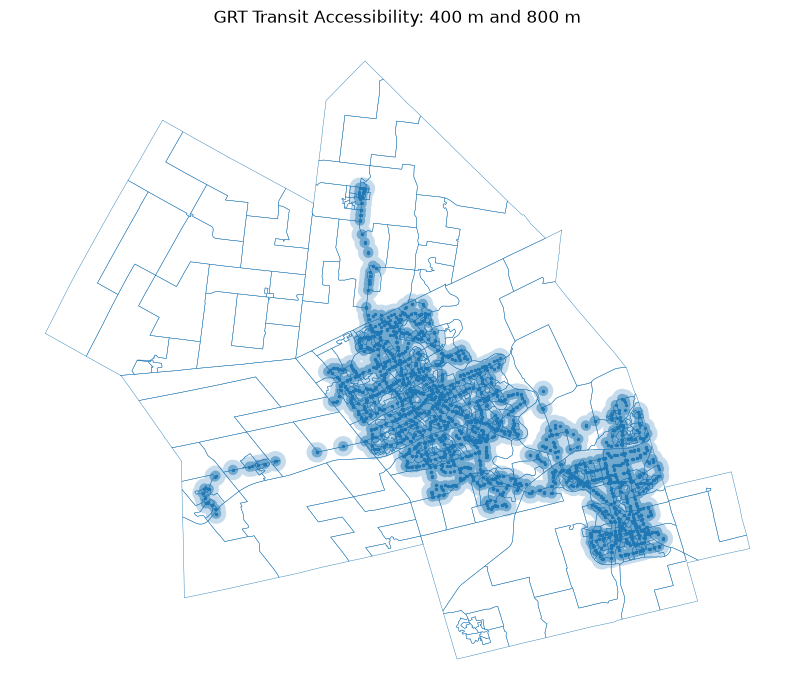

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

waterloo_da_pop.boundary.plot(
    ax=ax,
    linewidth=0.3
)

gpd.GeoSeries(
    [access_800],
    crs="EPSG:26917"
).plot(
    ax=ax,
    alpha=0.25
)

gpd.GeoSeries(
    [access_400],
    crs="EPSG:26917"
).plot(
    ax=ax,
    alpha=0.5
)

stops_projected.plot(
    ax=ax,
    markersize=2
)

ax.set_title("GRT Transit Accessibility: 400 m and 800 m")
ax.set_axis_off()

plt.show()

In [15]:
waterloo_da_pop["da_area"] = waterloo_da_pop.geometry.area

In [16]:
waterloo_da_pop["access_400_geom"] = (
    waterloo_da_pop.geometry.intersection(access_400)
)

In [17]:
waterloo_da_pop["access_400_area"] = (
    waterloo_da_pop["access_400_geom"].area
)

In [18]:
waterloo_da_pop["access_400_ratio"] = (
    waterloo_da_pop["access_400_area"]
    / waterloo_da_pop["da_area"]
)

In [19]:
waterloo_da_pop[
    ["DAUID", "Population", "da_area", "access_400_area", "access_400_ratio"]
].head()

,DAUID,Population,da_area,access_400_area,access_400_ratio
0,35300742,542.0,2.067209e+07,0.0,0.0
1,35300743,502.0,3.401332e+07,0.0,0.0
2,35300744,415.0,9.908855e+06,0.0,0.0
3,35300745,682.0,2.724843e+07,0.0,0.0
4,35300746,560.0,5.381499e+06,0.0,0.0


In [20]:
print("Total DAs:", len(waterloo_da_pop))

print(
    "DAs with 400m access:",
    (waterloo_da_pop["access_400_ratio"] > 0).sum()
)

print(
    "DAs with no 400m access:",
    (waterloo_da_pop["access_400_ratio"] == 0).sum()
)

print(
    "Maximum coverage ratio:",
    waterloo_da_pop["access_400_ratio"].max()
)

print(
    "Mean coverage ratio:",
    waterloo_da_pop["access_400_ratio"].mean()
)

Total DAs: 766
DAs with 400m access: 705
DAs with no 400m access: 61
Maximum coverage ratio: 1.0000000000000013
Mean coverage ratio: 0.7914008883024163


In [21]:
waterloo_da_pop.loc[
    waterloo_da_pop["access_400_ratio"] > 0,
    ["DAUID", "Population", "da_area", "access_400_area", "access_400_ratio"]
].head(10)

,DAUID,Population,da_area,access_400_area,access_400_ratio
5,35300296,3283.0,397267.041562,397267.041562,1.000000
6,35300297,1454.0,614560.355037,593944.793910,0.966455
7,35300298,2340.0,446959.604670,446959.604670,1.000000
8,35300329,399.0,63246.959539,63246.959539,1.000000
9,35300330,520.0,143125.937215,143125.937215,1.000000
10,35300332,299.0,146044.686513,118973.017057,0.814634
11,35300333,630.0,151404.994835,151383.996228,0.999861
12,35300334,251.0,309892.301133,241763.130533,0.780152
13,35300335,615.0,96802.166319,96802.166319,1.000000
14,35300338,766.0,137315.778445,137315.778445,1.000000


In [22]:
print(waterloo_da_pop["access_400_ratio"].min())
print(waterloo_da_pop["access_400_ratio"].max())

0.0
1.0000000000000013


In [23]:
waterloo_da_pop["pop_access_400"] = (
    waterloo_da_pop["Population"]
    * waterloo_da_pop["access_400_ratio"]
)

total_pop_400 = waterloo_da_pop["pop_access_400"].sum()

pct_400 = (
    total_pop_400
    / waterloo_da_pop["Population"].sum()
    * 100
)

print(f"Total population: {waterloo_da_pop['Population'].sum():,.0f}")
print(f"Estimated population within 400 m: {total_pop_400:,.0f}")
print(f"Estimated share within 400 m: {pct_400:.1f}%")

Total population: 587,165
Estimated population within 400 m: 437,870
Estimated share within 400 m: 74.6%


In [24]:
waterloo_da_pop["access_800_geom"] = (
    waterloo_da_pop.geometry.intersection(access_800)
)

waterloo_da_pop["access_800_area"] = (
    waterloo_da_pop["access_800_geom"].area
)

waterloo_da_pop["access_800_ratio"] = (
    waterloo_da_pop["access_800_area"]
    / waterloo_da_pop["da_area"]
)

In [25]:
print(
    "Min 800m ratio:",
    waterloo_da_pop["access_800_ratio"].min()
)

print(
    "Max 800m ratio:",
    waterloo_da_pop["access_800_ratio"].max()
)

print(
    "DAs with some 800m access:",
    (waterloo_da_pop["access_800_ratio"] > 0).sum()
)

Min 800m ratio: 0.0
Max 800m ratio: 1.0000000000000013
DAs with some 800m access: 717


In [26]:
waterloo_da_pop["pop_access_800"] = (
    waterloo_da_pop["Population"]
    * waterloo_da_pop["access_800_ratio"]
)

total_pop_800 = waterloo_da_pop["pop_access_800"].sum()

pct_800 = (
    total_pop_800
    / waterloo_da_pop["Population"].sum()
    * 100
)

print(f"Total population: {waterloo_da_pop['Population'].sum():,.0f}")
print(f"Estimated population within 800 m: {total_pop_800:,.0f}")
print(f"Estimated share within 800 m: {pct_800:.1f}%")

Total population: 587,165
Estimated population within 800 m: 506,721
Estimated share within 800 m: 86.3%


In [27]:
print(total_pop_800 >= total_pop_400)
print(pct_800 >= pct_400)

True
True


In [28]:
total_population = waterloo_da_pop["Population"].sum()

pop_400 = total_pop_400
pop_400_to_800 = total_pop_800 - total_pop_400
pop_beyond_800 = total_population - total_pop_800

pct_400_to_800 = pct_800 - pct_400
pct_beyond_800 = 100 - pct_800

print(f"Within 400 m: {pop_400:,.0f} ({pct_400:.1f}%)")
print(f"400–800 m:    {pop_400_to_800:,.0f} ({pct_400_to_800:.1f}%)")
print(f"Beyond 800 m: {pop_beyond_800:,.0f} ({pct_beyond_800:.1f}%)")

Within 400 m: 437,870 (74.6%)
400–800 m:    68,851 (11.7%)
Beyond 800 m: 80,444 (13.7%)


In [29]:
boundary_path = Path(
    "../data/raw/boundaries/waterloo_municipal_boundaries.geojson"
)

municipalities = gpd.read_file(boundary_path)
municipalities_projected = municipalities.to_crs("EPSG:26917")

In [30]:
print(municipalities_projected.crs)
print(municipalities_projected[["Municipality", "FullName"]])

EPSG:26917
     Municipality                    FullName
0       Cambridge           City of Cambridge
1       Kitchener           City of Kitchener
2  North Dumfries  Township of North Dumfries
3        Waterloo            City of Waterloo
4       Wellesley       Township of Wellesley
5          Wilmot          Township of Wilmot
6        Woolwich        Township of Woolwich


In [31]:
da_points = waterloo_da_pop.copy()

da_points["geometry"] = (
    da_points.geometry.representative_point()
)

In [32]:
da_with_municipality = gpd.sjoin(
    da_points,
    municipalities_projected[
        ["Municipality", "FullName", "geometry"]
    ],
    how="left",
    predicate="within"
)

In [33]:
da_with_municipality[
    ["DAUID", "Population", "Municipality", "FullName"]
].head()

,DAUID,Population,Municipality,FullName
0,35300742,542.0,Woolwich,Township of Woolwich
1,35300743,502.0,Woolwich,Township of Woolwich
2,35300744,415.0,Woolwich,Township of Woolwich
3,35300745,682.0,Woolwich,Township of Woolwich
4,35300746,560.0,Woolwich,Township of Woolwich


In [34]:
print(
    "Missing municipality:",
    da_with_municipality["Municipality"].isna().sum()
)

Missing municipality: 0


In [35]:
municipality_summary = (
    da_with_municipality
    .groupby("FullName")
    .agg(
        Population=("Population", "sum"),
        Pop_Access_400=("pop_access_400", "sum"),
        Pop_Access_800=("pop_access_800", "sum")
    )
    .reset_index()
)

In [36]:
municipality_summary["Pct_Access_400"] = (
    municipality_summary["Pop_Access_400"]
    / municipality_summary["Population"]
    * 100
)

municipality_summary["Pct_Access_800"] = (
    municipality_summary["Pop_Access_800"]
    / municipality_summary["Population"]
    * 100
)

In [37]:
municipality_summary[
    [
        "FullName",
        "Population",
        "Pct_Access_400",
        "Pct_Access_800"
    ]
].sort_values(
    "Pct_Access_400",
    ascending=False
)

,FullName,Population,Pct_Access_400,Pct_Access_800
0,City of Cambridge,138479.0,83.810201,96.130022
1,City of Kitchener,256885.0,82.904523,94.186612
2,City of Waterloo,121436.0,80.957539,92.236193
5,Township of Wilmot,21429.0,25.278555,47.013038
6,Township of Woolwich,26999.0,18.882166,35.023564
3,Township of North Dumfries,10619.0,0.137133,1.049848
4,Township of Wellesley,11318.0,0.000000,0.000000


In [38]:
stops_with_municipality = gpd.sjoin(
    stops_projected,
    municipalities_projected[
        ["FullName", "geometry"]
    ],
    how="left",
    predicate="within"
)

In [39]:
stop_counts = (
    stops_with_municipality
    .groupby("FullName")
    .size()
    .reset_index(name="Stop_Count")
)

stop_counts.sort_values(
    "Stop_Count",
    ascending=False
)

,FullName,Stop_Count
1,City of Kitchener,995
0,City of Cambridge,657
2,City of Waterloo,515
4,Township of Woolwich,48
3,Township of Wilmot,31


In [40]:
all_municipalities = municipalities_projected[
    ["FullName"]
].copy()

stop_counts_complete = all_municipalities.merge(
    stop_counts,
    on="FullName",
    how="left"
)

stop_counts_complete["Stop_Count"] = (
    stop_counts_complete["Stop_Count"]
    .fillna(0)
    .astype(int)
)

In [41]:
stop_counts_complete.sort_values(
    "Stop_Count",
    ascending=False
)

,FullName,Stop_Count
1,City of Kitchener,995
0,City of Cambridge,657
3,City of Waterloo,515
6,Township of Woolwich,48
5,Township of Wilmot,31
2,Township of North Dumfries,0
4,Township of Wellesley,0


In [42]:
municipality_analysis = municipality_summary.merge(
    stop_counts_complete,
    on="FullName",
    how="left"
)

In [43]:
municipality_analysis["Pct_Access_400"] = (
    municipality_analysis["Pct_Access_400"].round(1)
)

municipality_analysis["Pct_Access_800"] = (
    municipality_analysis["Pct_Access_800"].round(1)
)

In [44]:
municipality_analysis[
    [
        "FullName",
        "Population",
        "Stop_Count",
        "Pct_Access_400",
        "Pct_Access_800"
    ]
].sort_values(
    "Pct_Access_400",
    ascending=False
)

,FullName,Population,Stop_Count,Pct_Access_400,Pct_Access_800
0,City of Cambridge,138479.0,657,83.8,96.1
1,City of Kitchener,256885.0,995,82.9,94.2
2,City of Waterloo,121436.0,515,81.0,92.2
5,Township of Wilmot,21429.0,31,25.3,47.0
6,Township of Woolwich,26999.0,48,18.9,35.0
3,Township of North Dumfries,10619.0,0,0.1,1.0
4,Township of Wellesley,11318.0,0,0.0,0.0


In [45]:
waterloo_da_pop["Pct_Access_400"] = (
    waterloo_da_pop["access_400_ratio"] * 100
)

waterloo_da_pop["Pct_Access_800"] = (
    waterloo_da_pop["access_800_ratio"] * 100
)

In [46]:
waterloo_da_pop["Pop_Beyond_800"] = (
    waterloo_da_pop["Population"]
    - waterloo_da_pop["pop_access_800"]
)

In [47]:
underserved_ranked = waterloo_da_pop[
    [
        "DAUID",
        "Population",
        "Pct_Access_400",
        "Pct_Access_800",
        "Pop_Beyond_800",
        "geometry"
    ]
].sort_values(
    "Pop_Beyond_800",
    ascending=False
)

In [48]:
underserved_ranked[
    [
        "DAUID",
        "Population",
        "Pct_Access_400",
        "Pct_Access_800",
        "Pop_Beyond_800"
    ]
].head(10)

,DAUID,Population,Pct_Access_400,Pct_Access_800,Pop_Beyond_800
756,35301060,5504.0,12.538094,29.547777,3877.690374
751,35301033,9831.0,49.819657,69.746753,2974.196730
743,35301043,3885.0,13.112721,28.009390,2796.835179
750,35301048,2551.0,3.336938,11.387013,2260.517294
481,35300773,1981.0,0.000000,0.000000,1981.000000
22,35300804,1861.0,0.000000,0.000000,1861.000000
739,35301039,1751.0,0.000000,0.000000,1751.000000
746,35301044,3017.0,15.871757,43.139304,1715.487184
749,35301047,2585.0,2.816835,37.879617,1605.811902
629,35300936,1729.0,4.664905,9.514056,1564.501978


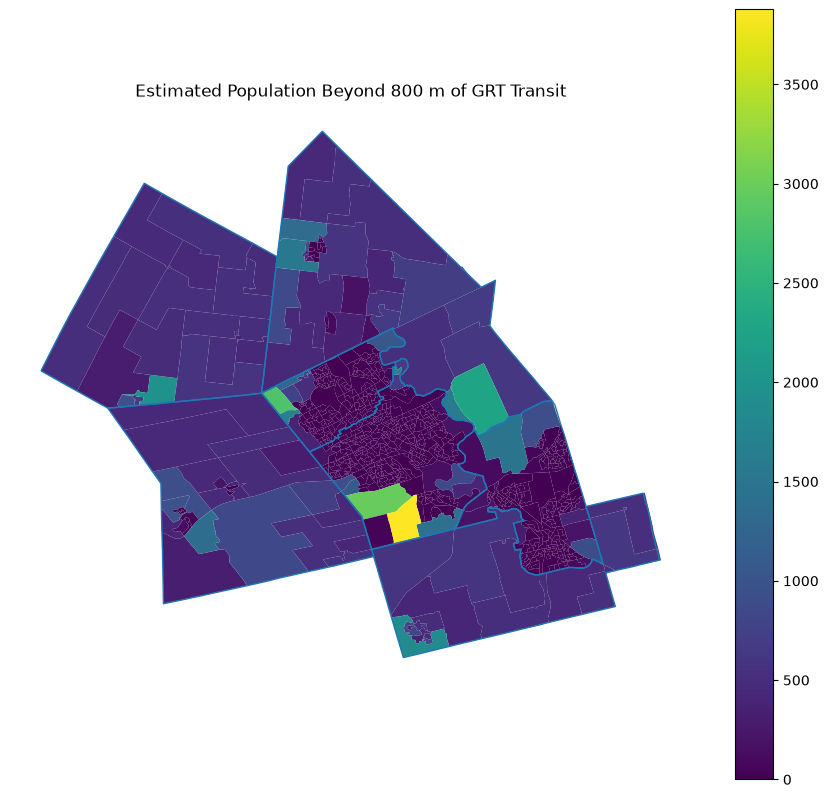

In [49]:
fig, ax = plt.subplots(figsize=(11, 10))

waterloo_da_pop.plot(
    ax=ax,
    column="Pop_Beyond_800",
    legend=True,
    linewidth=0.15
)

municipalities_projected.boundary.plot(
    ax=ax,
    linewidth=1
)

ax.set_title(
    "Estimated Population Beyond 800 m of GRT Transit"
)

ax.set_axis_off()

plt.show()

In [50]:
da_rep_points = waterloo_da_pop[
    ["DAUID", "geometry"]
].copy()

da_rep_points["geometry"] = (
    da_rep_points.geometry.representative_point()
)

In [51]:
da_municipality_lookup = gpd.sjoin(
    da_rep_points,
    municipalities_projected[
        ["FullName", "geometry"]
    ],
    how="left",
    predicate="within"
)

In [52]:
da_municipality_lookup = da_municipality_lookup[
    ["DAUID", "FullName"]
]

In [53]:
waterloo_da_pop = waterloo_da_pop.merge(
    da_municipality_lookup,
    on="DAUID",
    how="left"
)

In [54]:
print(
    "Missing municipality:",
    waterloo_da_pop["FullName"].isna().sum()
)

print(
    "Unique municipalities:",
    waterloo_da_pop["FullName"].nunique()
)

Missing municipality: 0
Unique municipalities: 7


In [55]:
underserved_ranked = waterloo_da_pop.sort_values(
    "Pop_Beyond_800",
    ascending=False
)

underserved_ranked[
    [
        "DAUID",
        "FullName",
        "Population",
        "Pct_Access_400",
        "Pct_Access_800",
        "Pop_Beyond_800"
    ]
].head(10)

,DAUID,FullName,Population,Pct_Access_400,Pct_Access_800,Pop_Beyond_800
756,35301060,City of Kitchener,5504.0,12.538094,29.547777,3877.690374
751,35301033,City of Kitchener,9831.0,49.819657,69.746753,2974.196730
743,35301043,City of Waterloo,3885.0,13.112721,28.009390,2796.835179
750,35301048,Township of Woolwich,2551.0,3.336938,11.387013,2260.517294
481,35300773,Township of Wellesley,1981.0,0.000000,0.000000,1981.000000
22,35300804,Township of North Dumfries,1861.0,0.000000,0.000000,1861.000000
739,35301039,City of Kitchener,1751.0,0.000000,0.000000,1751.000000
746,35301044,City of Waterloo,3017.0,15.871757,43.139304,1715.487184
749,35301047,Township of Woolwich,2585.0,2.816835,37.879617,1605.811902
629,35300936,Township of Woolwich,1729.0,4.664905,9.514056,1564.501978


In [56]:
top10_underserved = underserved_ranked.head(10).copy()

NameError: name 'label_points' is not defined

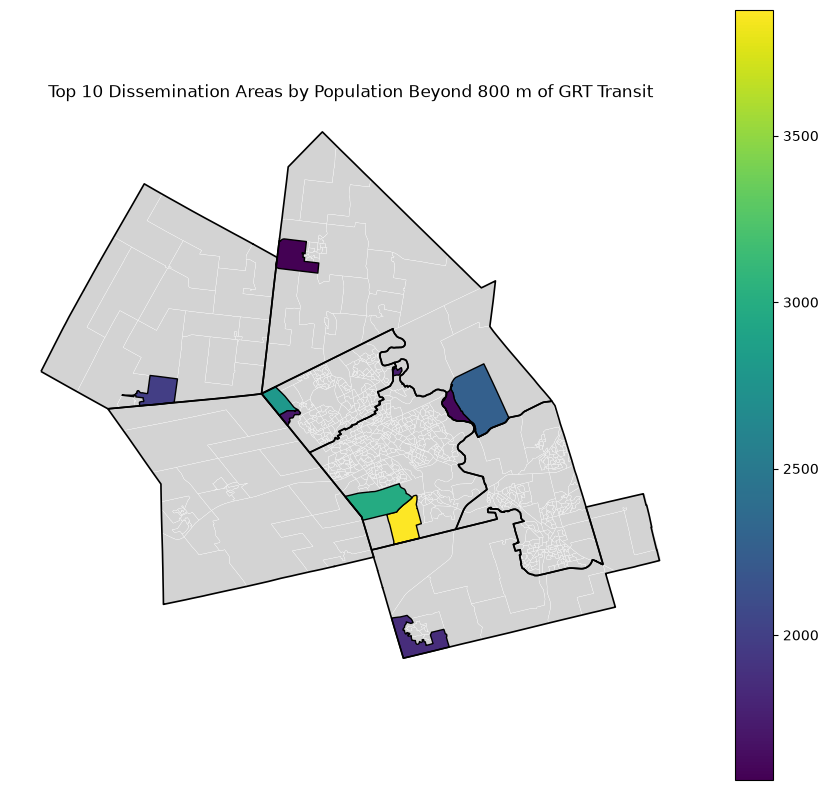

In [57]:
fig, ax = plt.subplots(figsize=(11, 10))

waterloo_da_pop.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.2
)

top10_underserved.plot(
    ax=ax,
    column="Pop_Beyond_800",
    legend=True,
    edgecolor="black",
    linewidth=1
)

municipalities_projected.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.set_title(
    "Top 10 Dissemination Areas by Population Beyond 800 m of GRT Transit"
)

ax.set_axis_off()
for _, row in label_points.iterrows():
    ax.annotate(
        text=row["DAUID"],
        xy=(row.geometry.x, row.geometry.y),
        fontsize=7,
        ha="center"
    )
plt.show()

In [ ]:
label_points = top10_underserved.copy()

label_points["geometry"] = (
    label_points.geometry.representative_point()
)

In [ ]:
waterloo_da_pop["Pct_Beyond_800"] = (
    100 - waterloo_da_pop["Pct_Access_800"]
)

In [ ]:
waterloo_da_pop[
    [
        "DAUID",
        "FullName",
        "Population",
        "Pct_Access_800",
        "Pct_Beyond_800",
        "Pop_Beyond_800"
    ]
].head()

,DAUID,FullName,Population,Pct_Access_800,Pct_Beyond_800,Pop_Beyond_800
0,35300742,Township of Woolwich,542.0,0.0,100.0,542.0
1,35300743,Township of Woolwich,502.0,0.0,100.0,502.0
2,35300744,Township of Woolwich,415.0,0.0,100.0,415.0
3,35300745,Township of Woolwich,682.0,0.0,100.0,682.0
4,35300746,Township of Woolwich,560.0,0.0,100.0,560.0


In [ ]:
priority_underserved = waterloo_da_pop[
    (waterloo_da_pop["Pct_Access_800"] < 50) &
    (waterloo_da_pop["Pop_Beyond_800"] >= 500)
].copy()

In [ ]:
print(
    "Priority underserved DAs:",
    len(priority_underserved)
)

print(
    "Estimated population beyond 800 m in these DAs:",
    f"{priority_underserved['Pop_Beyond_800'].sum():,.0f}"
)

Priority underserved DAs: 52
Estimated population beyond 800 m in these DAs: 49,712


In [ ]:
priority_underserved[
    "FullName"
].value_counts()

FullName
Township of Woolwich          15
Township of Wellesley         11
Township of North Dumfries    10
Township of Wilmot             6
City of Waterloo               5
City of Kitchener              4
City of Cambridge              1
Name: count, dtype: int64

In [ ]:
priority_underserved[
    [
        "DAUID",
        "FullName",
        "Population",
        "Pct_Access_800",
        "Pop_Beyond_800"
    ]
].sort_values(
    "Pop_Beyond_800",
    ascending=False
).head(15)

,DAUID,FullName,Population,Pct_Access_800,Pop_Beyond_800
756,35301060,City of Kitchener,5504.0,29.547777,3877.690374
743,35301043,City of Waterloo,3885.0,28.009390,2796.835179
750,35301048,Township of Woolwich,2551.0,11.387013,2260.517294
481,35300773,Township of Wellesley,1981.0,0.000000,1981.000000
22,35300804,Township of North Dumfries,1861.0,0.000000,1861.000000
739,35301039,City of Kitchener,1751.0,0.000000,1751.000000
746,35301044,City of Waterloo,3017.0,43.139304,1715.487184
749,35301047,Township of Woolwich,2585.0,37.879617,1605.811902
629,35300936,Township of Woolwich,1729.0,9.514056,1564.501978
735,35301020,Township of Wilmot,1652.0,17.083559,1369.779610


In [ ]:
print(
    "Priority underserved DAs:",
    len(priority_underserved)
)

print(
    "Estimated population beyond 800 m in these DAs:",
    f"{priority_underserved['Pop_Beyond_800'].sum():,.0f}"
)

print("\nPriority underserved DAs by municipality:")

print(
    priority_underserved["FullName"]
    .value_counts()
)

Priority underserved DAs: 52
Estimated population beyond 800 m in these DAs: 49,712

Priority underserved DAs by municipality:
FullName
Township of Woolwich          15
Township of Wellesley         11
Township of North Dumfries    10
Township of Wilmot             6
City of Waterloo               5
City of Kitchener              4
City of Cambridge              1
Name: count, dtype: int64


In [ ]:
priority_share = (
    priority_underserved["Pop_Beyond_800"].sum()
    / pop_beyond_800
    * 100
)

print(
    f"Share of all beyond-800m population located in priority DAs: "
    f"{priority_share:.1f}%"
)

Share of all beyond-800m population located in priority DAs: 61.8%


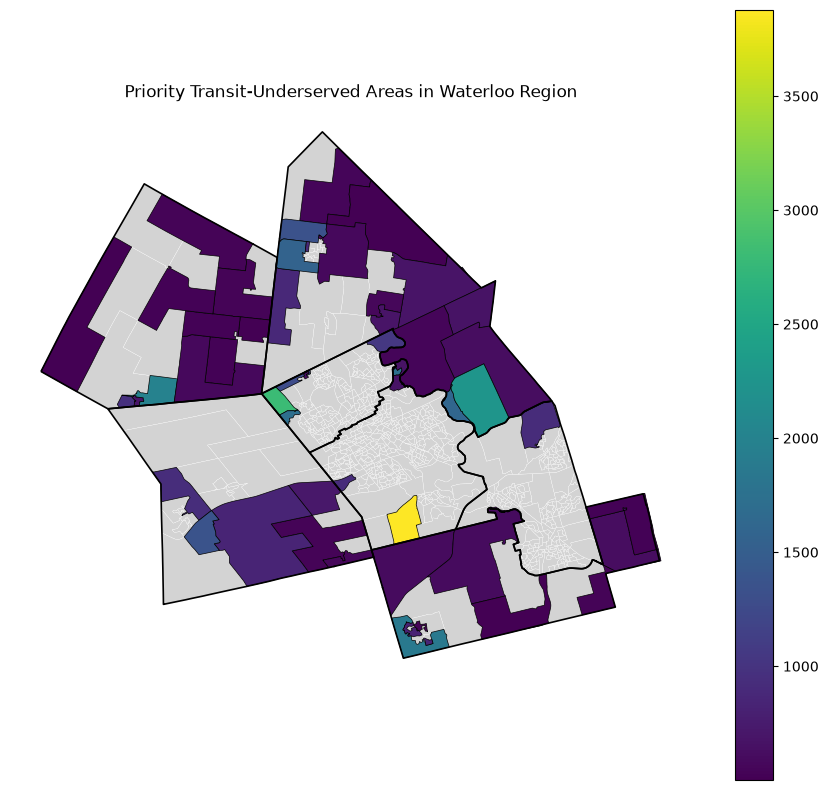

In [ ]:
fig, ax = plt.subplots(figsize=(11, 10))

# All Census DAs
waterloo_da_pop.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.2
)

# Priority underserved DAs
priority_underserved.plot(
    ax=ax,
    column="Pop_Beyond_800",
    legend=True,
    edgecolor="black",
    linewidth=0.5
)

# Municipal boundaries
municipalities_projected.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.set_title(
    "Priority Transit-Underserved Areas in Waterloo Region"
)

ax.set_axis_off()

plt.show()

In [ ]:
total_da_by_municipality = (
    waterloo_da_pop["FullName"]
    .value_counts()
    .rename("Total_DAs")
)

priority_da_by_municipality = (
    priority_underserved["FullName"]
    .value_counts()
    .rename("Priority_DAs")
)

priority_summary = pd.concat(
    [
        total_da_by_municipality,
        priority_da_by_municipality
    ],
    axis=1
).fillna(0)

priority_summary["Priority_DAs"] = (
    priority_summary["Priority_DAs"].astype(int)
)

priority_summary["Priority_DA_Pct"] = (
    priority_summary["Priority_DAs"]
    / priority_summary["Total_DAs"]
    * 100
)

priority_summary.sort_values(
    "Priority_DA_Pct",
    ascending=False
)

,Total_DAs,Priority_DAs,Priority_DA_Pct
FullName,,,
Township of North Dumfries,17,10,58.823529
Township of Wellesley,19,11,57.894737
Township of Woolwich,36,15,41.666667
Township of Wilmot,29,6,20.689655
City of Waterloo,155,5,3.225806
City of Kitchener,321,4,1.246106
City of Cambridge,189,1,0.529101


In [ ]:
waterloo_da_export = waterloo_da_pop.drop(
    columns=[
        "access_400_geom",
        "access_800_geom"
    ]
).copy()

In [ ]:
waterloo_da_export.columns

Index(['DAUID', 'DGUID', 'LANDAREA', 'PRUID', 'Population', 'geometry',
       'da_area', 'access_400_area', 'access_400_ratio', 'pop_access_400',
       'access_800_area', 'access_800_ratio', 'pop_access_800',
       'Pct_Access_400', 'Pct_Access_800', 'Pop_Beyond_800', 'FullName',
       'Pct_Beyond_800'],
      dtype='str')

In [ ]:
waterloo_da_export.to_file(
    processed_path / "waterloo_accessibility.gpkg",
    layer="da_accessibility",
    driver="GPKG"
)

In [ ]:
priority_export = priority_underserved.drop(
    columns=[
        "access_400_geom",
        "access_800_geom"
    ]
).copy()

In [ ]:
priority_export.to_file(
    processed_path / "waterloo_accessibility.gpkg",
    layer="priority_underserved",
    driver="GPKG"
)

In [ ]:
municipality_analysis.to_csv(
    processed_path / "municipality_accessibility.csv",
    index=False
)

In [ ]:
print(
    (processed_path / "waterloo_accessibility.gpkg").exists()
)

print(
    (processed_path / "municipality_accessibility.csv").exists()
)

True
True
